<a href="https://colab.research.google.com/github/minguzi-s/PyNps/blob/main/20_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D%2C_%EC%8B%AC%EC%B8%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ■ 인공신경망
Artificial Neural Network(ANN)

In [ ]:
# 목표: 딥러닝과 인공 신경망 알고리즘을 이해하고 TensorFlow 를 사용해 간단한 인공신경망 모델을 만들어 봅니다.

# 핵심키워드 : 인공신경망, 텐서플로, 밀집층(DenseLayer), 원-핫 인코딩 (One-hot encodint)
# 핵심 패키지와 함수 : Dense, Sequential, compile(), fit(), evaludate()

# 데이터셋 : FashionMNIST

# FashionMNIST 데이터셋

- **FashionMNIST** 는 숫자 대신 패션 아이템 이미지로 구성
  - 28x28 gray scale 이미지
  - 10 classes

![](https://www.dropbox.com/scl/fi/sedguh6ct6pnis3rbedgt/FashionMNIST01.png?rlkey=0ne4aolsni15ir812xgcnv6af&st=o7656heb&dl=1)

  - 많은 딥러닝 라이브러리에서 이 데이터를 가져올수 있도록 제공함

In [ ]:
# 우선 FasionMNIST 가 어떤 데이터인지 확인해보자

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, random

In [ ]:
# tensorflow
import tensorflow as tf

# TF  에서 제공하는 고수준 API keras
from tensorflow import keras
# import keras

print(tf.__version__)  # TF 버젼
print(keras.__version__)

2.19.0
3.13.2


In [ ]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고
# 텐서플로 연산을 '결정적'으로 만듭니다.
def set_seed(seed = 42):
  tf.keras.utils.set_random_seed(seed)

  # tf.config.experimental.enable_op_determinism()
  # TF 로 하여금 deterministic 하게 동작하도록 설정함
  # -> 동일 input, 동일 HW 에서 동작시 매번 동일한 결과를 낼수 있도록 한다
  #    GPU 에서 이를 설정시 성능관련하여 명백히 느려진다.
  # https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism

In [ ]:
# FasionMNIST 데이터를 다운로드 하여 '입력' 과 '타킷' 의 쌍 으로 리턴한다.
(train_input, train_target), (test_input, test_target) =\
            keras.datasets.fashion_mnist.load_data()

# 훈련 데이터의 크기를 확인해보자
print(train_input.shape, train_target.shape) # (60000, 28, 28) (60000,)
# test 세트의 크기  10000장의 데이터
print(test_input.shape, test_target.shape) # (10000, 28, 28) (10000,)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
# '훈련'데이터는 총 60000장의 gray scale 이미지 (h, w) 는 (28, 28)
#   (60000, 28, 28) <- (batch, height, width)
# '훈련 타겟'데이터는 60000개 원소를 가진 1차원 배열

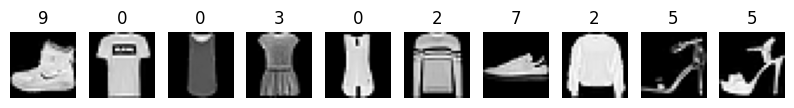

In [ ]:
# 첫 10장 샘플 시각화
fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
    axs[i].set_title(train_target[i]) # 타겟
    axs[i].imshow(train_input[i], cmap='gray')  # 이미 배경이 검정색이라 gray_r 대신 gray
    axs[i].axis('off')
plt.show()

In [ ]:
# FashionMNIST 의 레이블 의미
# 0      1       2       3      4     5      6     7         8      9
# 티셔츠 바지   스웨터  드레스   코트   샌달   셔츠   스니커즈   가방   앵클부츠

In [ ]:
# 각 레이블당 샘플 개수도 확인해보자
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


## 전처리 (정규화)

In [ ]:
# 정규화
# 각 픽셀값 0~255 -> 0~1 사이의 값으로 '정규화'
# 양수 값으로만 이루어진 이미지를 전처리 할때 많이 사용하는 방법
train_scaled = train_input / 255.0

# 우선 1차원 배열로 펼치기
train_scaled = train_scaled.reshape(-1, 28*28)

print(train_scaled.shape)  # (60000, 784)

# 정규화 결과 확인
print('스케일전', np.min(train_input), np.max(train_input))
print('스케일후', np.min(train_scaled), np.max(train_scaled))

(60000, 784)
스케일전 0 255
스케일후 0.0 1.0


# 인공 신경망 으로 분류하기
Artificial neural network (**ANN**)

In [ ]:
# 사실 인공신경망은 '확률적 경사 하강법' 을 사용하는 로지스틱 회귀와 같다

# FashionMNIST 분류 문제를 인공 신경망으로 표현해 보도록 하자

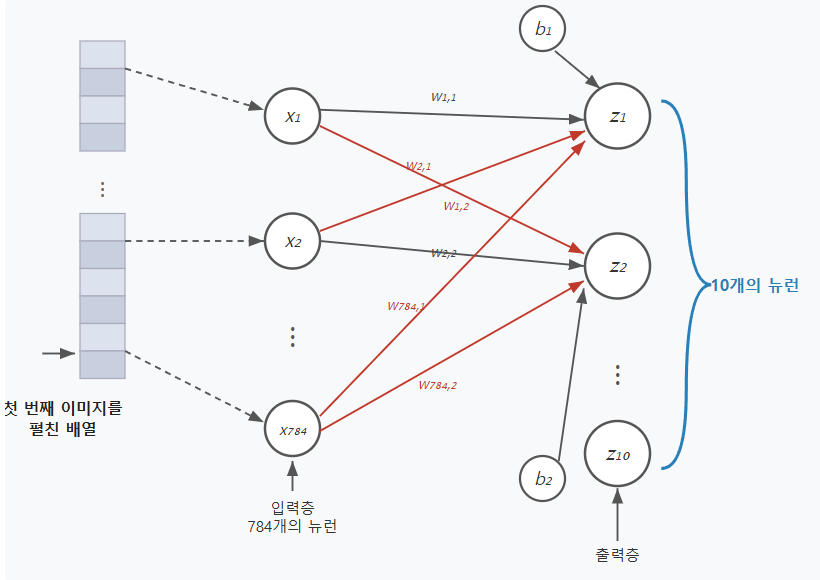

- 출력층, 입력층

![](https://www.dropbox.com/scl/fi/4een71k0n4iisq8gbzvwp/Neuron00.png?rlkey=ykmn3jf9hyhvehlu6q1rmvsae&st=eruzi9jr&dl=1)

![](https://static.wikidocs.net/images/page/236181/%EC%9D%B8%EA%B3%B5%EC%A7%80%EB%8A%A5_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_%EB%94%A5%EB%9F%AC%EB%8B%9D.png)

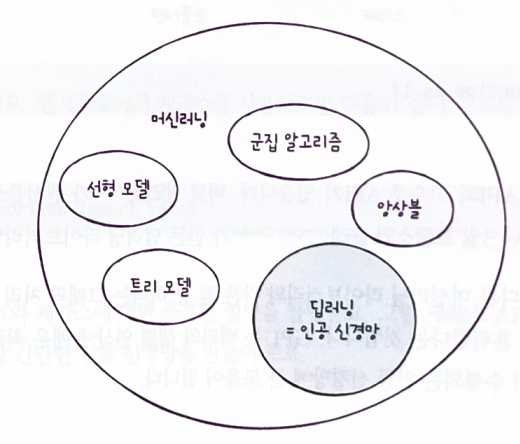

# 인공신경망으로 모델 만들기

In [ ]:
# 인공신경망에서는 '교차검증' 을 잘 사용하지 않고 검증 세트를 별도로 덜어내어 사용하곤 함.
#    - 이유1 :  딥러닝 분야의 데이터셋은 이미 충분히 크다.  (검증 점수가 안정적)
#    - 이유2 :  교차검증 수행하기에 훈련시간이 너무 오래 걸린다.

In [ ]:
from sklearn.model_selection import train_test_split
# ★한번만 실행하세요

# 훈련세트에서 20%를 검증 세트를 나누어 덜어 내어봅니다
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

# 훈련세트와 검증세트 크기
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)
# (48000, 784) (48000,)
# (12000, 784) (12000,)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [ ]:
# 인공신경망을 다음과 같이 만들어보자
# 10개의 패션 아이템을 분류하기 위해 10개의 뉴런으로 구성됩니다

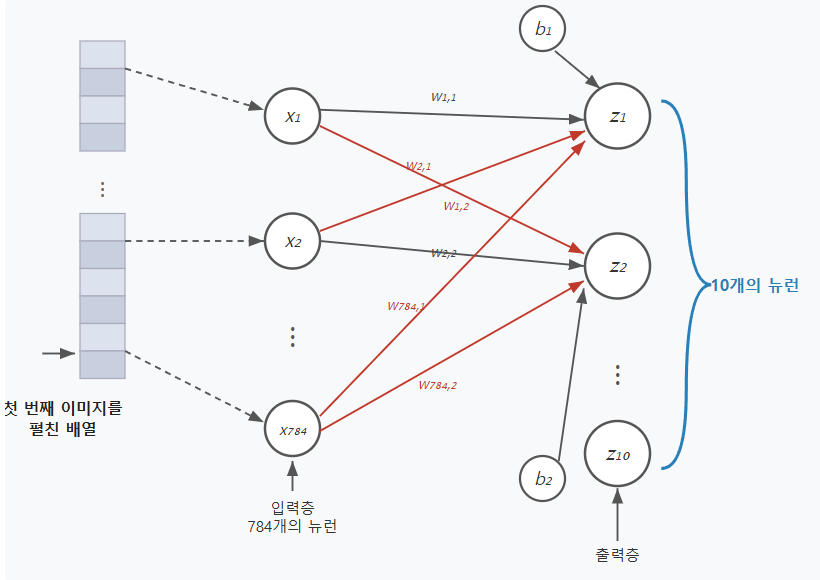

### Dense Layer
밀집층

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSv2ABGkovif5KFtoEY0cDegI-H8GK2GHU03MNYB8q4Xg&s)

In [ ]:
# keras.layers 패키지 안에는 다양한 층이 준비 되어 있다

In [ ]:
#  (784 + 1) x 10 = 7850 개의 연결된 선!  빽빽하다 -> Dense Layer
#  양쪽 층이 '모두' 연결되어 있기 때문에  -> Fully Connected Layer (완전 연결층) 이라고도 한다

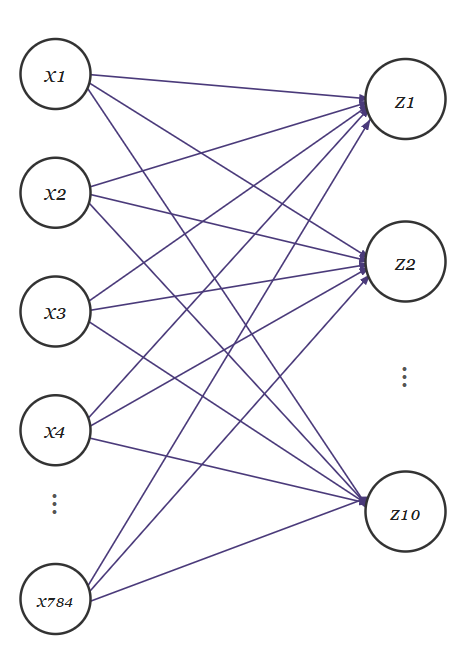

![](https://epynn.net/_images/Dense-01.svg)

**Input**

https://www.tensorflow.org/api_docs/python/tf/keras/Input
```python
tf.keras.Input(
    shape=None,  # 입력 shape
    batch_size=None,
    dtype=None,
    sparse=None,
    batch_shape=None,
    name=None,
    tensor=None
)
```

**Dense**

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

```python
tf.keras.layers.Dense(
    units,  # 뉴런개수
    activation=None,  # 출력에 적용할 활성화 함수
    use_bias=True,
    kernel_initializer='glorot_uniform',
    bias_initializer='zeros',
    kernel_regularizer=None,
    bias_regularizer=None,
    activity_regularizer=None,
    kernel_constraint=None,
    bias_constraint=None,
    lora_rank=None,
    **kwargs
)
```

In [ ]:
# 입력층
# shape=(784,) : 입력의 크기
inputs = keras.Input(shape=(784,))

#  Dense(뉴런개수, 뉴런의 출력에 적용할 함수)
dense = keras.layers.Dense(units=10, activation='softmax')

# units=10 : 패션이미지를 분류하는 문제 (10개의 클래스)
# activation='softmax': 출력값을 확률값으로 변환 (다중분류문제)


## 모델 생성

In [ ]:
# 이제 위 밀집층을 가진 신경망 모델을 만들어 보자
# keras 의 Sequential 클래스를 사용해 보겠습니다

**Sequential**

https://www.tensorflow.org/api_docs/python/tf/keras/Sequential

```python
tf.keras.Sequential(
    layers=None,
    trainable=True,
    name=None
)
```

In [ ]:
model = keras.Sequential(layers=[inputs, dense])

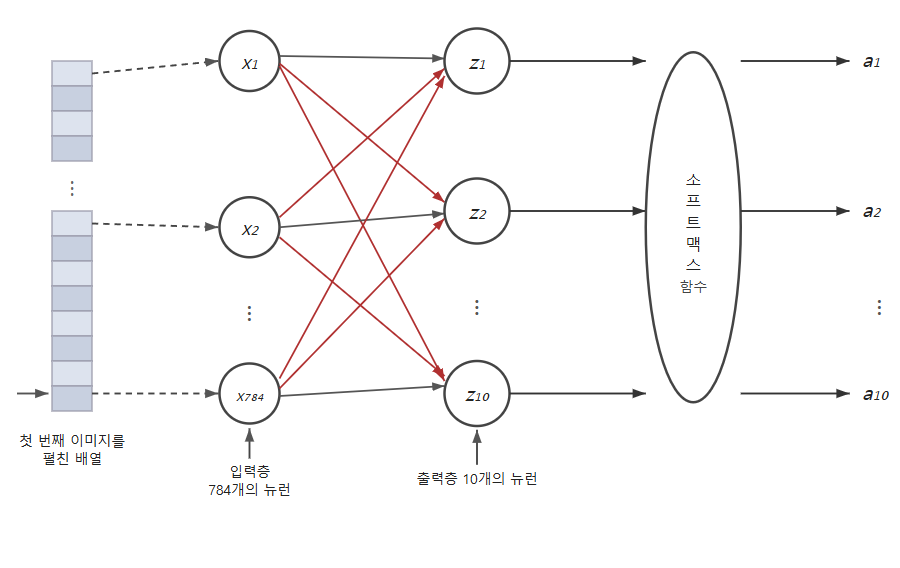

# 인공신경망으로 분류하기

## compile()


In [ ]:
# keras 모델 훈련전 모델 설정 단계
# compile()
#     loss=  손실함수 지정 (★필수!)
#     metrics= 훈련과정에서 계산하고픈 측정값

**compile()**

https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile

```python
compile(
    optimizer='rmsprop',  # 경사하강법 알고리즘
    loss=None,    # loss 함수
    loss_weights=None,
    metrics=None,  # 측정방법
    weighted_metrics=None,
    run_eagerly=False,
    steps_per_execution=1,
    jit_compile='auto',
    auto_scale_loss=True
)
```

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])


### loss=

In [ ]:
# 어떤 손실함수를 사용하나?
#                                             keras 에선 이렇게 나누어 부른다
#  이진분류 : 이진 크로스 엔트로피 손실 함수 사용  ->  loss='binary_crossentropy'
#  다중분류 : 크로스 엔트로피 손실 함수 사용
#      one-hot 형태 -> loss='categorical_crossentropy'
#      정수값 형태 -> loss='sparse_categorical_crossentropy'

In [ ]:
# 패션 MNIST 데이터의 타겟 값은 어떻게 되어 있었나요?
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [ ]:
# 그러나 TF 에선 정수로 된 타켓값을 One-Hot 으로 변경하지 않아도 사용 가능!
# => sparse_categorical_crossentropy

### metrics=

In [ ]:
# keras 는 모델훈련시 epoch 마다 loss 값 출력.
# loss 값이 줄어드는것 뿐 아니라, metrics 에 명시한 accuracy 도 함께 출력함.

"""
이제 compile ( ) 메서드 의 두 번째 매개 변수 인 metrics 에 대해 알아 보죠 .
케라스는 모델 이 훈련 할 때 기본 으로 에포크 마다 손실 값 을 출력 해 줍니다 .
손실 이 줄어드는 것을 보고 훈련 이 잘 되었다는 것 을 알 수 있지만
정확도 를 함께 출력 하면 더 좋겠죠 .

이를 위해 metrics 매개변수에 '정확도'지표 를 의미 하는 'accuracy' 를 지정 했습니다 .
"""
None

In [ ]:
"""
자 이제 모델 을 훈련 해 보죠 . 훈련 하는 fit ( ) 메서드 는 사이 킷런 과 매우 비슷 합니다 .
처음 두 매개 변수 에 입력 ( train_scaled ) 과 타깃 ( train_traget ) 을 지정 합니다 .
그다음 반복 할 에포크 횟수 를 epochs 매개 변수 로 지정 합니다 .
사이킷런 의 로지스틱 모델 과 동일 하게 5 번 반복 해 보겠습니다 .
"""
None

## fit() 훈련

https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit

```python
fit(
    x=None,  # 입력데이터
    y=None,  # 타겟데이터
    batch_size=None,  # 배치 크기 (기본 32)
    epochs=1,   # 에포크
    verbose='auto',
    callbacks=None,
    validation_split=0.0,
    validation_data=None,
    shuffle=True,
    class_weight=None,
    sample_weight=None,
    initial_epoch=0,
    steps_per_epoch=None,
    validation_steps=None,
    validation_batch_size=None,
    validation_freq=1
)
```

In [ ]:
model.fit(train_scaled, train_target, epochs=5)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7937 - loss: 0.6043
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8386 - loss: 0.4749
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8483 - loss: 0.4508
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8528 - loss: 0.4373
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8538 - loss: 0.4289


In [ ]:
# ※ 결과는 여러분들과 다를수 있습니다!
# 인공신경망을 만들고 훈련할 때 랜덤하게 동작하는 특성때문.
#   모델이 최적점에 안정적으로 수렴한다면 일반적으로 이 차이는 크기 않습니다

# keras 는 mini-batch 사용
#  기본 배치 크기는 32개
#  훈련데이터 크기 48000개 -> 1500개의 배치

# step : 한번의 batch 를 수행하고 weight 업데이트 계산하는 단위.
#    - 세션 내에서 '순전파 → 역전파 →  가중치갱신'이라는 하나의 과정이 일어난 횟수
#    - Iteration Step 등으로 불리기도 한다

## evaluate() 평가

https://www.tensorflow.org/api_docs/python/tf/keras/Model#evaluate

```python
evaluate(
    x=None,
    y=None,
    batch_size=None,
    verbose='auto',
    sample_weight=None,
    steps=None,
    callbacks=None,
    return_dict=False,
    **kwargs
)
```

In [ ]:
model.evaluate(val_scaled, val_target)  # 검증점수

#      loss           ,   accuracy
# [0.43963879346847534, 0.8502500057220459]

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8503 - loss: 0.4396


[0.43963879346847534, 0.8502500057220459]

In [ ]:
"""
▶사이킷런 모델
                               손실 함수      반복 횟수
                                   ↓             ↓
모델 → sc = SGDClassifier ( loss = 'log_loss' , max_iter = 5 )
훈련 → sc.fit ( train_scaled , train_target )
평가 → sc.score ( val_scaled , val_target )

▶케라스 모델
                          층 생성
                                ↓
     dense = keras.layers.Dense(10 , activation = ' softmax ')

모델 →  model = keras.Sequential ( dense )
                                   손실 함수
        model.compile (loss='sparse_categorical_crossentropy', metrics = 'accuracy ' )
훈련 →  model.fit ( train_scaled , train_target , epochs = 5 )
평가 →  model.evaluate ( val_scaled , val_target )   ↑반복 횟수
"""
None

# ■ 심층 신경망 (DNN: Deep Neural Network)
여러개의 hidden layer 추가하기

In [ ]:
# 목표: 인공신경망에 층을 여러 개 추가하여 패션 MNIST 데이터셋을 분류하면서
#       케라스로 심층 신경망을 만드는 방법을 자세히 배웁니다.

# 핵심키워드 : 심층 신경망, 렐루 함수, 옵티마이저
# 핵심 패키지와 함수 : add(), summary(),
            # 옵티마이저들 -> SGD, Adagrad, RMSprop, Adam

# 데이터셋 : FashionMNIST

## 은닉층 (hidden layer)

In [ ]:
# 은닉층 (hidden layer) : 입력층과 출력층 사이의 레이어(들)

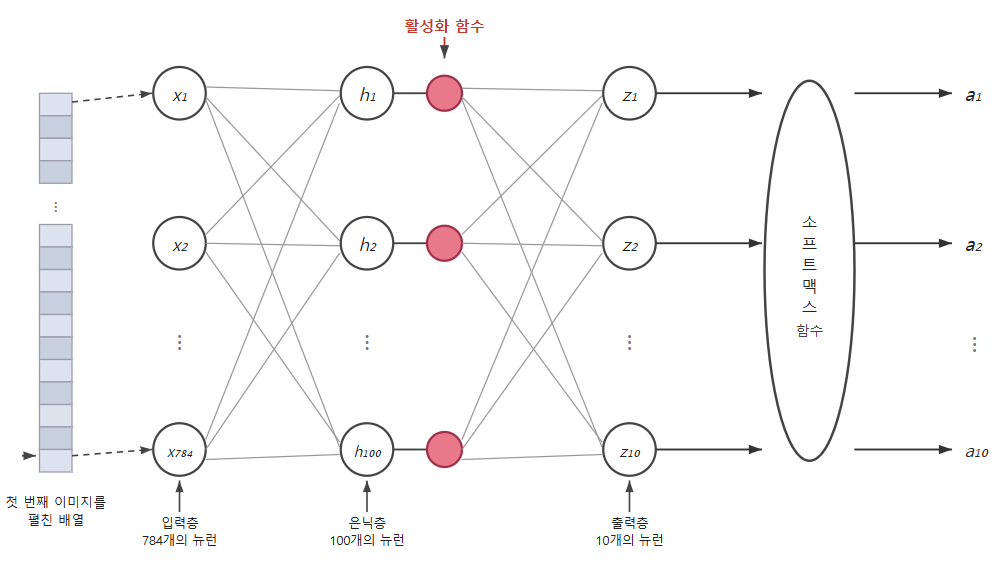

## 활성화 함수 (activation function)

In [ ]:
# 활성화 함수 (activation function)
#  : 선형방정식 계산결과에 적용되는 함수

#  출력층에 적용되는 활성화 함수는 제한적
#       이진분류 -> 시그모이드 함수,  다중분류는 -> 소프트 맥스   ★(분류모델에서 쓰는 활성화 함수)

#  반면, 은닉층에 적용되는 활성화 함수는 다양하다!
#       sigmoid, ReLu, Tanh...

In [ ]:
# 참고] 회귀모델에 출력층에 사용하는 활성화 함수? => '필요없다!'
#    회귀의 출력은 '임의의 숫자'이기 때문에.
#    출력층의 선형방정식 계산결과를 그대로 출력.
#    이 경우 Dense layer 의 activation= 매개변수에 값을 지정하지 않습니다.

## 2개의 layer 만들기

In [ ]:
# 시그모이드 함수를 사용한 은닉층 과 소프트맥스 함수를 사용한 출력층
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='sigmoid')
dense2 = keras.layers.Dense(10, activation='softmax')

In [ ]:
# 은닉층의 뉴런의 개수는? <- 경험과 실험을 통해 알아 나가야 됨.
# 출력층의 뉴런개수보다는 많아야 함!!


## DNN 모델 만들기

In [ ]:
# 심층 신경망 (deep neural network, DNN) 만들기
model = keras.Sequential([inputs, dense1, dense2])
# 명심! 출력층을 가장 마지막에 두어야 한다.

In [ ]:
# keras 는 모델의 layer 에 대한 정보를 출력해준다
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ↑ 모델에 들어있는 layer 의 순서대로 나열
# 각 layer 마다 이름, 클래스, 출력크기, 모델파라미터 개수가 출력.

## 모델 파라미터의 개수

In [ ]:
# 모델 파라미터의 개수는?

# dense1 의 parameter
#     78500  =  (입력 784  + bias) x 100

# dense2 의 parameter
#      1010  =  (입력 100 + bias) x 10

![](https://www.dropbox.com/scl/fi/5fet32yi65rg9lt01wgts/hiddenlayer01.jpg?rlkey=t6rxdb914q7u6ij906v16wlgz&st=ahjta4xw&dl=1)

![](https://www.dropbox.com/scl/fi/9rawl7oxevo29n1qk88l7/hiddenlayer02.jpg?rlkey=yaaqjdgrb81madprwwr9cjv4h&st=8nqqf8cm&dl=1)

## layer 를 추가하는 다른 방법들

In [ ]:
# Sequential 클래스에 layer 를 추가하는 다른 방법

model = keras.Sequential([
  keras.layers.Input(shape=(784,)),
  keras.layers.Dense(100, activation='sigmoid', name='hidden'),
  keras.layers.Dense(10, activation='softmax', name='output')
], name='Fashion MNIST 모델')

model.summary()

Model: "Fashion MNIST 모델"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# add() 사용하여 layer 추가하기

model = keras.Sequential()

model.add(keras.layers.Input(shape=(784,)))
model.add(keras.layers.Dense(units=100, activation='sigmoid', name='hidden'))
model.add(keras.layers.Dense(units=10, activation='softmax', name='output'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden (Dense)                  │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

## DNN 학습 ▶

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8046 - loss: 0.5698
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8517 - loss: 0.4104
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8633 - loss: 0.3760
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8723 - loss: 0.3520
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8782 - loss: 0.3345


In [ ]:
# 이전의 단일 layer 로 했을때와 비교해보자.
# accuracy 는 증가했고, loss 감소
# 학습시간은 더 걸렸다.

# 활성화 함수

## 기울기 소실  문제
활성화 함수 때문에.. 역전파시 기울기 소실 발생 (vanishing gradient)

![](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2FokTU1%2FbtrCH4Fx7Ro%2Fm5f9UkRkl7CP3dUEgXTtk1%2Fimg.png)

## ReLU 활성화 함수

![](https://blog.kakaocdn.net/dn/vgJna/btqQzRGmwcO/TK3KTMlz4CYag8rBTKfYkK/img.png)

ReLU : '렐루'

In [ ]:
# 이미지 분류에 많이 사용되는 활성화 함수, DNN 에서 뛰어난 성능.

## Flatten Layer 소개

In [ ]:
# Flatten layer
#   batch 차원을 제외하고 나머지 입력차원을 모두 일렬로 펼치는 역할
#   입력에 곱해지는 가중치나 절편은 없다.
#   즉 모델 파라미터 없고, 학습하는 층이 아니라 -> 모델의 성능에 영향을 주는 레이어는 아니다

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))  # 입력을 2차원으로 받자!
model.add(keras.layers.Flatten()) # (28, 28) => (784,)
model.add(keras.layers.Dense(100, activation='relu'))  # <- 첫번째 Dense 층의 활성화 함수를 'relu' 로 변경!
model.add(keras.layers.Dense(10, activation='softmax'))

# ↑ 그러나 이 신경망을 '깊이가 3' 인 신경망이라 부르진 않습니다.
# Flatten 은 학습하는 층이 아니니까!

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
↑ 첫번째 Flatten 클래스에 포함된 모델 파라미터는 0 이다!

keras 의 Flatten 층을 신경망 모델에 추가함으로 얻는 장점은
=>  '입력값의 차원' 을 짐작할수 있다는 점입니다.

앞의 출력에서 784개의 입력이 첫번째 은닉층에 전달된다는 것을 알수 있습니다.
이는 이전에 만들었던 모델에서는 쉽게 눈치채기 어려웠습니다.  (앞선 summary 결과와 대조해보자)

>> '입력데이터에 대한 전처리 과정'을 가능한 모델에 포함시키는 것이 keras API 철학중 하나입니다.

"""
None



## 입력데이터 다시 준비

In [ ]:
# 이제 훈련데이터를 다시 준비해서 모델을 훈련시켜 보겠습니다.
# 이번에는 reshape() 를 적용하지 않고 해보겠습니다

# 입력을 (28, 28) 로 전해주어야 하니
# 입력데이터를 다시 준비

(train_input, train_target), (test_input, test_target) = \
         keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

train_scaled.shape
# (48000, 28, 28) (?, h, w) 를 그대로 입력!

(48000, 28, 28)

## 학습▶, 검증

In [ ]:
# 모델 컴파일, 훈련
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(train_scaled, train_target, epochs=5)

# ↓ 이제 검증 세트에서의 성능도 확인해 보겠습니다
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8130 - loss: 0.5310
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8584 - loss: 0.3923
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8734 - loss: 0.3545
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8806 - loss: 0.3322
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8859 - loss: 0.3170
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8789 - loss: 0.3535


[0.35354092717170715, 0.8789166808128357]

In [ ]:
# ↑ sigmoid 함수를 사용했을때보다 ReLU 함수를 사용했을때가 더 효과가 좋다!

In [ ]:
# 지금까지의 모델은 5번의 epoch 동안 훈련했다.
# 더 많은 epoch 를 훈련해볼수도 있다.

# 그 전에 인공신경망 의 '하이퍼 파라미터' 에 대해 알아보자

# 인공신경망의 하이퍼 파라미터들

In [ ]:
# '하이퍼 파라미터'
#   모델이 학습하는 파라미터 가 아니다
#   학습전에 사람이 지정해 주어야 하는 파라미터다.

# 인공신경망에서의 하이퍼 파라미터들은 많~다
#   (지금까지 배운 범위 에선 다음과 같은 하이퍼 파라미터 들이 있다)
#   - 추가할 은닉층의 개수
#   - 각 층의 뉴런 개수
#   - 활성화 함수
#   - 층의 종류
#   - 배치(batch) 사이즈 : fit() 의 batch_size= 매개변수
#   - epoch : fit()  의 epochs= 매개변수

# Optimizer 경사하강법 알고리즘
- 옵티마이저,
- keras 가 제공하는 경사하강법 알고리즘(들)

In [ ]:
# keras 는 기본적으로 '미니배치 경사하강법' 을 사용한다

#  미니배치(mini-batch) 의 개수 기본값은 32개 입니다
#  fit() 의 batch_size= 매개변수에서 이를 조정해줄수 있다

#  경사하강법 알고리즘은
#  compile() 의 optimizer= 매개변수에서 이를 설정해줄수 있다
#  기본값은 RMSprop 사용.

# keras 는 다양한 종류의 경사하강법 알고리즘 제공하며
#   이를 옵티마이저 (optimizer) 라 한다
# 어떠한 옵티마이저 를 선택할른지도 하이퍼 파라미터다.

# 경사하강법 알고리즘의 학습률(learning rate) 파라미터 또한 조정가능한 하이퍼 파라미터다.

- Convex function (볼록 함수)

![](https://www.dropbox.com/scl/fi/9mnfctswjimxs8me3vdue/optimizer01.png?rlkey=yycfx6v9pcioegf1s9leqw052&st=lx2h8ak8&dl=1)

- Non-convec function (비볼록 함수)

![](https://www.dropbox.com/scl/fi/hfv7wize0lyiwc00tcace/optimizer02.gif?rlkey=xnhm6kn01ui62z4vrs4fe47ta&st=li5ea71q&dl=1)

- local minimum

![](https://www.dropbox.com/scl/fi/plmkfh53murms6bb8nlpd/optimizer03.png?rlkey=5zwtvoqnlfjb0fiwnx4xw02le&st=57u0151s&dl=1)

- saddle point 문제

![](https://www.dropbox.com/scl/fi/02kbs96uoxmhzzaxk63sx/optimizer04.png?rlkey=mm1lpslox2yt6h2l5vf19d12w&st=vsxxkukn&dl=1)

- momentum
![](https://www.dropbox.com/scl/fi/0ik84pdqk9lbqynve2fys/optimizer05.png?rlkey=vvdkq5clx5tuwh9xo0chcua5p&st=necosz36&dl=1)

- learning rate
![](https://www.dropbox.com/scl/fi/c66dpy2n7xxde8u7sl230/optimizer06.png?rlkey=5bdgl9mryokega713wdi98wxj&st=xko1chfd&dl=1)

### SGD optimizer

**tf.keras.optimizers.SGD**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD

```python
tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.0,
    nesterov=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='SGD',
    **kwargs
)
```

In [ ]:
# SGD optimizer 는 확률적 경사하강법 사용
#  그런데 이름에서 풍기는 (Stochastic ..) 것과는 달리
#  1개의 샘플을 뽑아서 훈련하지는 않고,  앞서 언급한 것처럼 이또한 미니배치(mini-batch) 를 사용합니다

In [ ]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 위 optimizer 는
# tensorflow.keras.optimizers 패키지 아래 SGD 클래스에 구현되어 있다
# 위에서처럼 'sgd' 문자열로 지정하면.  SGD 클래스의 기본설정 매개변수로 생성한 객체와 동일하게 생성된다.

# 즉 위의 코드는 아래와 같이 작성한 코드와 정확히 동일하다

In [ ]:
sgd = keras.optimizers.SGD(learning_rate=0.02, momentum=0.001)

model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# ↑  keras 에선 위와 같이 객체를 직접 생성해도 되고 혹은 'sgd' 와 같이 문자열로 주어도 기본 매개변수로 객체를 생성해주도록
#   설계되어 있는 것들이 많다

### learning rate=
학습률

In [ ]:
# SGD 클래스의 learning rate (학습률) 기본값을 0.01 이다
# 이를 변경하려면 learing_rate= 매개변수를 지정해준다

sgd = keras.optimizers.SGD(learning_rate=0.1)

## 다양한 Optimizer 들

In [ ]:
"""

  기본경사 하강법 옵티마이저

      learning_rate=0.01         momentum>0               nesterov=True
            [SGD] ---------------> [모멘텀] ----------> [네스테로프 모멘텀]
                                      │
                                      │
   적응적 학습률 옵티마이저            │
  (Adaptive learning rate)            │
                                      ↓
          [RMSprop]  ------------> [Adam]
                learning_rate=0.001

          [Adagrad]

"""
None
# ↓ 아래 설명

### 기본경사하강법 (SGD)

#### momentum=

In [ ]:
# momentum= 기본값은 0
#    (사용할 경우 일반적으로 0.9 이상을 사용함 -> 그레디언트 가속도 적용 -> '모멤텀 최적화' 사용)

#### nesterov=

In [ ]:
# nesterov=True 로 주면
# '네스테로프 모멘텀 최적화 (nesterov momentum optimization, 또는 네스테로프 가속 경사)' 를 사용

# 모멘텀 최적화는 '2번 반복'
# 일반적으로 기본모멘텀 최적화보다는 나은 성능 기대

In [ ]:
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

### adaptive learning rate (적응적 학습률)
AdaGrad, RMSprop
---
**tf.keras.optimizers.Adagrad**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adagrad


```python
tf.keras.optimizers.Adagrad(
    learning_rate=0.001,
    initial_accumulator_value=0.1,
    epsilon=1e-07,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='adagrad',
    **kwargs
)
```

---
**tf.keras.optimizers.RMSprop**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/RMSprop


```python
tf.keras.optimizers.RMSprop(
    learning_rate=0.001,
    rho=0.9,
    momentum=0.0,
    epsilon=1e-07,
    centered=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='rmsprop',
    **kwargs
)
```


In [ ]:
# '적응적 학습률 (adaptive learning rate)'
# 모델의 최적점 가까이 갈수록 학습률을 낮추어 나감.
#  => 안정적인 최적점에 수렴할 가능성 높임.
#  => 학습률 매개변수를 튜닝하는 수고를 덜수 있다.

# 대표: AdaGrad ('adagrad'),
#       RMSprop ('rmsprop') (디폴트!)

# 위 두 옵티마이저의 매개변수들을 조정하고 싶다면 아래와 같이 클래스 객체를 만들어 사용하면 된다.

In [ ]:
adagrad = keras.optimizers.Adagrad()  # <- 생성자에 매개변수 지정해주면 된다
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
rmsprop = keras.optimizers.RMSprop()  # <- 생성자에 매개변수 지정해주면 된다
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

#### Adam 옵티마이저

**tf.keras.optimizers.Adam**

https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam

```python
tf.keras.optimizers.Adam(
    learning_rate=0.001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    weight_decay=None,
    clipnorm=None,
    clipvalue=None,
    global_clipnorm=None,
    use_ema=False,
    ema_momentum=0.99,
    ema_overwrite_frequency=None,
    loss_scale_factor=None,
    gradient_accumulation_steps=None,
    name='adam',
    **kwargs
)
```

In [ ]:
# Adam: 모멘텀 최적화 와 RMSprop 의 장점을 접목


In [ ]:
# Adam 클래스의 기본 매개변수값으로 FashionMNIST 를 훈련해보자

# 학습▶, 검증

In [ ]:
set_seed(42)

# 모델 생성
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())  # (28, 28) => (784,)
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

# 모델 컴파일, Adam optimizer 사용
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(train_scaled, train_target, epochs=5)

# 검증
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8160 - loss: 0.5220
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8600 - loss: 0.3900
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8732 - loss: 0.3495
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8834 - loss: 0.3216
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8894 - loss: 0.3020
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8737 - loss: 0.3509


[0.35090649127960205, 0.8736666440963745]

In [ ]:
# [0.35354092717170715, 0.8789166808128357]

# [0.35090649127960205, 0.8736666440963745]

# 문제해결 과정
- keras API 를 활용한 DNN (심층신경망)

  - 여러개의 층을 추가하여 DNN 생성
  - 다양한 방법으로 추가하는 방법
  - summary() 사용, 출력값의 의미,
  - 모델파라미터의 개수 계산
    - 모델을 제대로 이해했는지 확인하는 방법중 하나
  - 은닉충에 사용하는 활성화 함수
  - ReLu 활성화 함수
  - 다양한 경사 하강법 옵티마이저 적용하는 방법

- keras 를 사용하면 이런 작업이 어렵지 않고 직관적으로 구성할수 있다.

In [ ]:
# 검증세트로 모델의 성능을 확인
# evaluate()
model.evaluate(val_scaled, val_target)

In [ ]:
# p360 SGD Classifier 보다 놀은 성능

In [ ]:
# p361
# SGDClassifier 와 keras 모델간의 차이점